In [9]:
import librosa
import numpy as np
import matplotlib.pyplot as plt
import pywt
from PyEMD import EMD, Visualisation
from vmdpy import VMD
from sklearn.decomposition import FastICA

In [2]:
files = {
    'piano': 'data/piano.wav',
    'audiobook': 'data/book_1min.wav',
    'city': 'data/zvuki-i-shum-ulicy-goroda_1min.wav',
    'baraban': 'data/baraban-z_uk.wav'
}

signals = {}

for name, path in files.items():
    y, sr = librosa.load(path, duration=60)
    signals[name] = (y, sr)

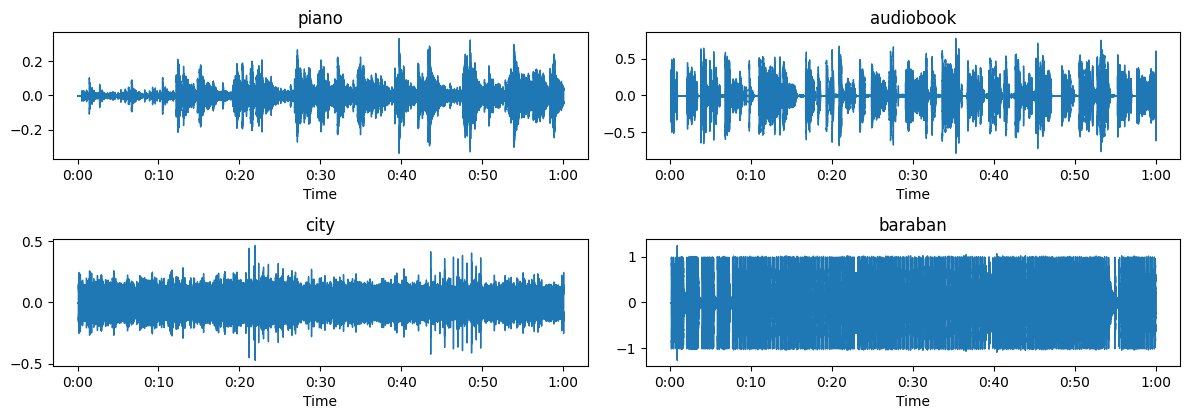

In [20]:
# осцилограммы
plt.figure(figsize=(12, 8))

for i, (name, (y, sr)) in enumerate(signals.items(), 1):
    plt.subplot(4, 2, i)
    librosa.display.waveshow(y, sr=sr)
    plt.title(name)

plt.tight_layout()

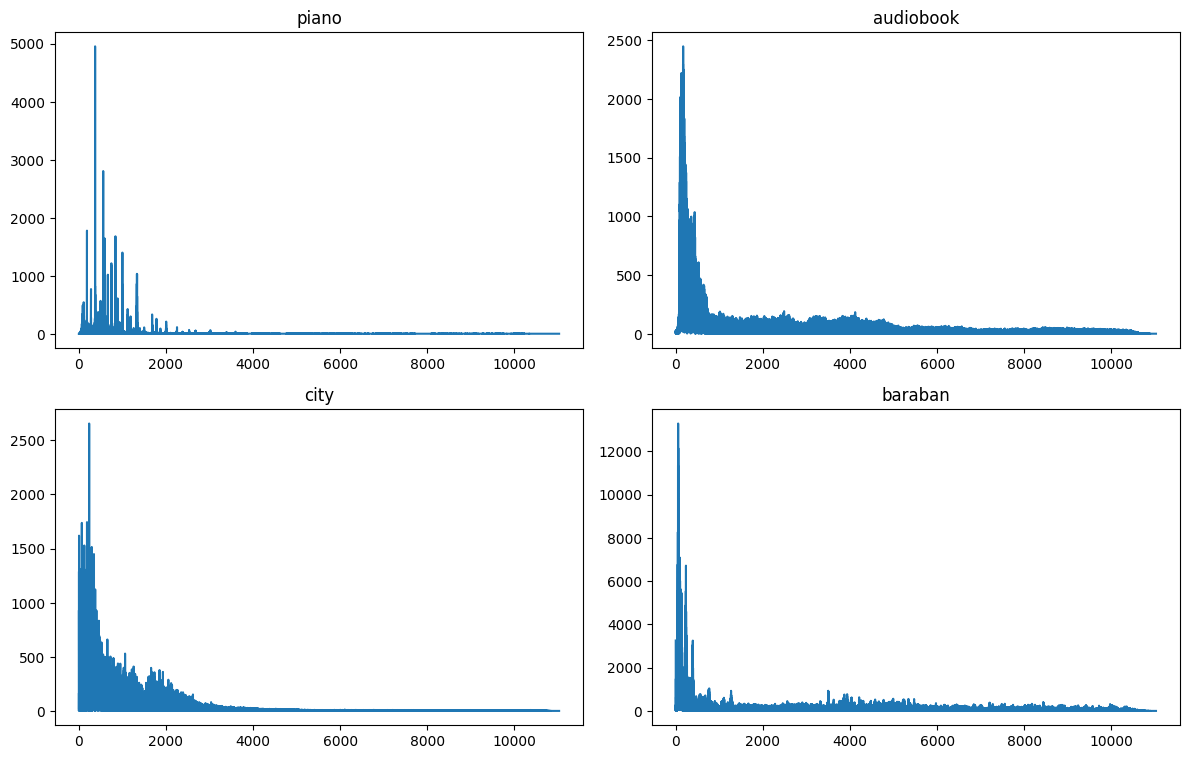

In [19]:
# быстрое преобразование фурье fft - какие частоты были в сигнале
plt.figure(figsize=(12, 15))

for i, (name, (y, sr)) in enumerate(signals.items(), 1):
    fft_vals = np.fft.fft(y)
    frequencies = np.fft.fftfreq(len(y), 1/sr)

    idx = frequencies >= 0

    plt.subplot(4, 2, i)
    plt.plot(frequencies[idx], np.abs(fft_vals[idx]))
    plt.title(name)

plt.tight_layout()

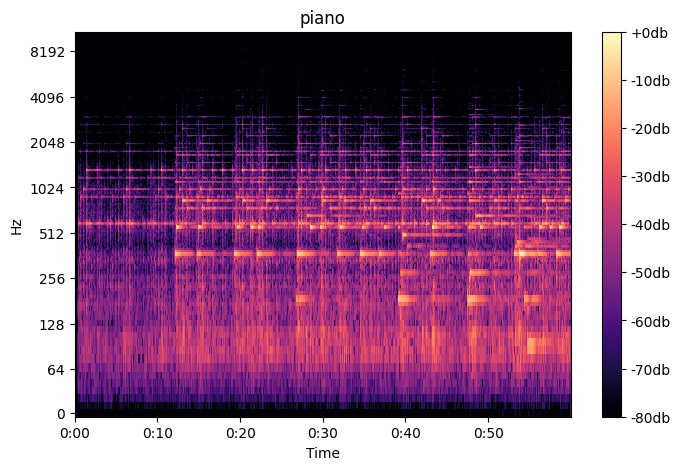

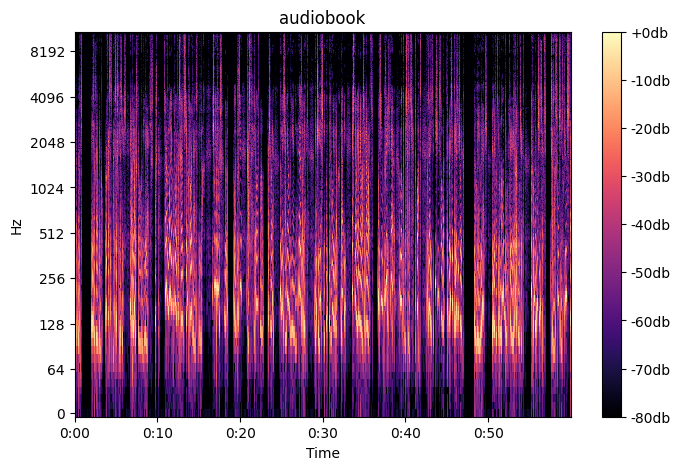

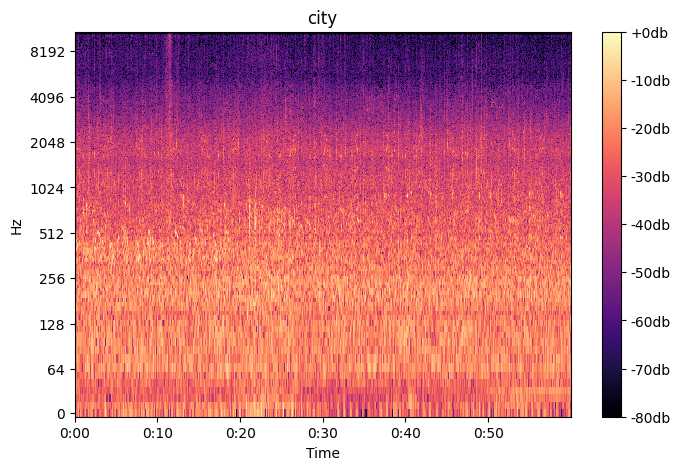

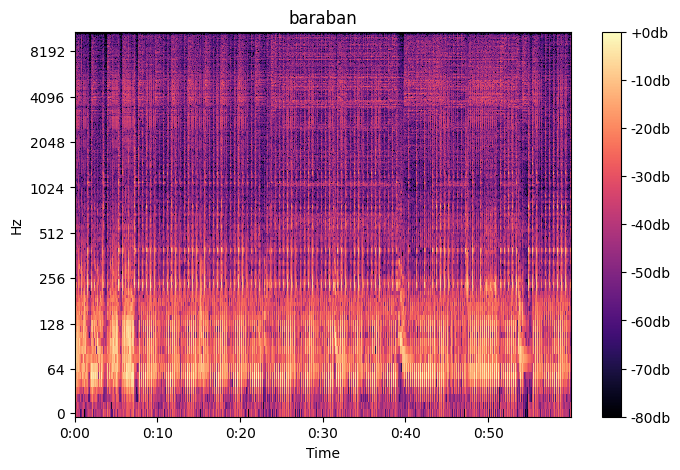

In [21]:
# оконное преобразование Фурье (спектрограмма) stft - разделяет сигнал на окна и применяет FFT к каждому окну
stfts = {name: librosa.stft(y) for name, (y, _) in signals.items()}

for i, (name, (y, sr)) in enumerate(signals.items(), 1):
    s_mag, _ = librosa.magphase(stfts.get(name))
    s_pow = s_mag ** 2
    s_db = librosa.power_to_db(s_pow, ref=np.max)

    plt.figure(figsize=(8, 5))
    librosa.display.specshow(s_db, sr=sr, x_axis='time', y_axis='log')
    plt.colorbar(format='%+2.0fdb')
    plt.title(name)

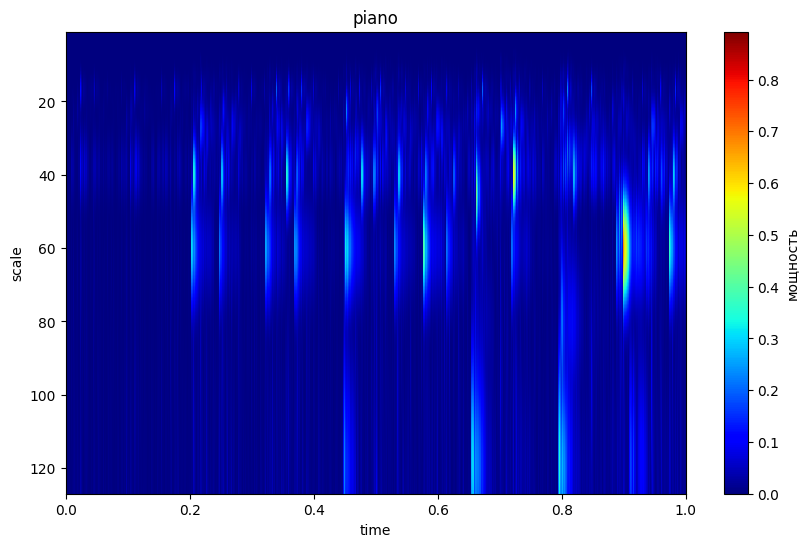

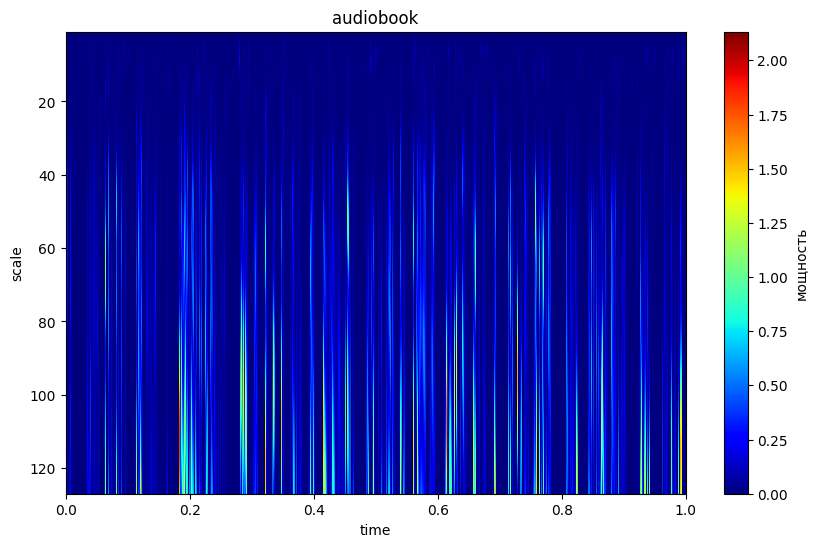

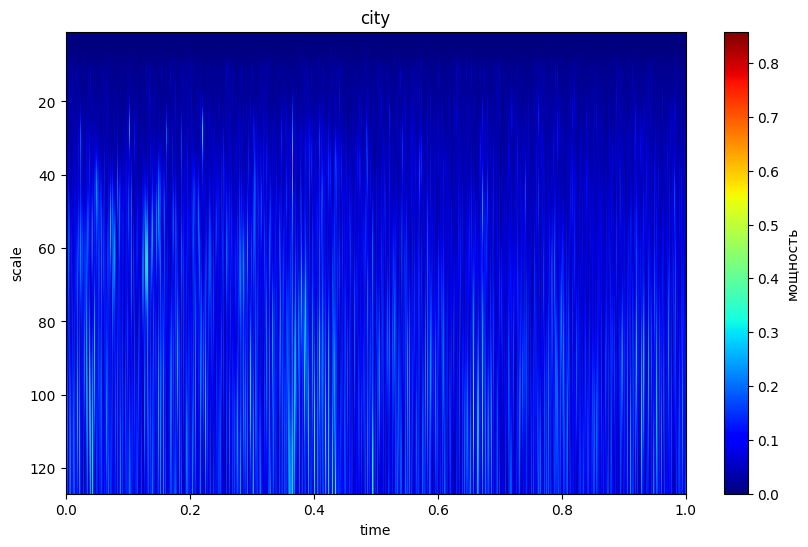

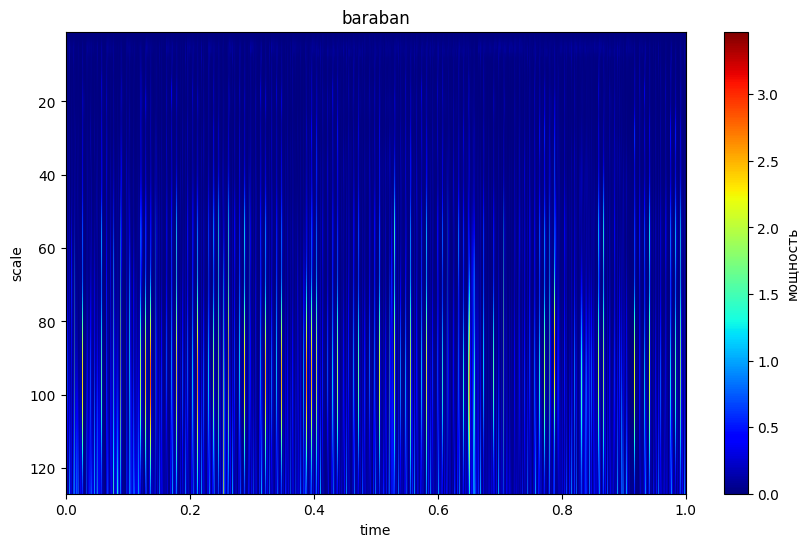

In [24]:
# непрерывное вейвлет-преобразование cwt - поиска аномалий, разрывов и нестационарных частот
scales = np.arange(1, 128) 
wavelet_name = 'cmor1.5-1.0'

for name, (y, sr) in signals.items():
    coefficients, frequencies = pywt.cwt(y, scales, wavelet_name, sampling_period=1/400)

    plt.figure(figsize=(10, 6))

    plt.imshow(np.abs(coefficients), extent=[0, 1, scales[-1], scales[0]], 
           aspect='auto', cmap='jet', vmax=abs(coefficients).max())
    plt.colorbar(label='мощность')
    plt.title(name)
    plt.ylabel('scale')
    plt.xlabel('time')

найдено IMF: 10


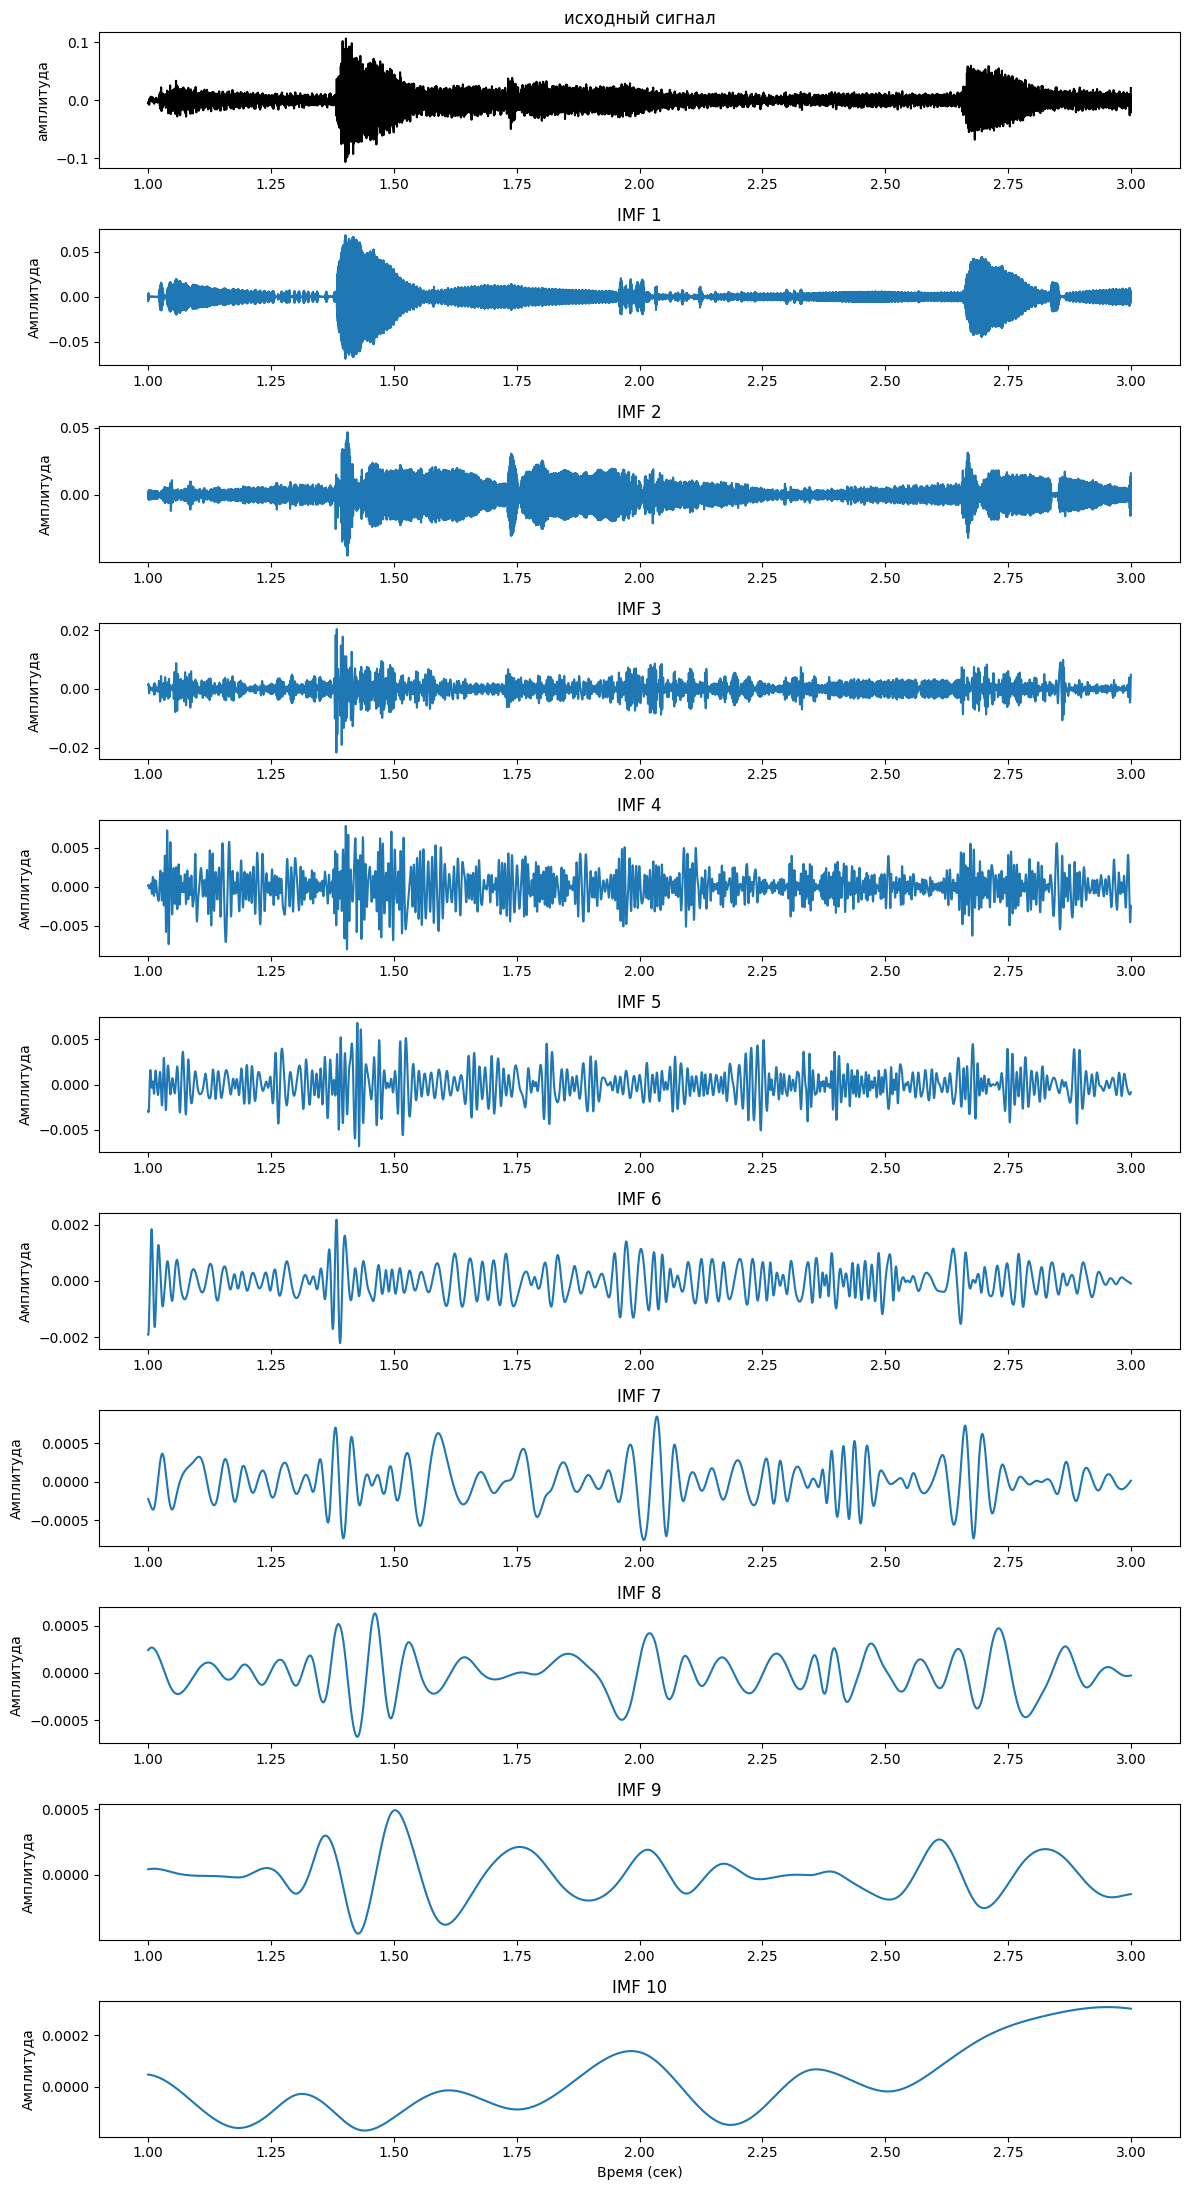

In [5]:
# эмпирическая модовая декомпозиция (EMD) - раскладывает сигнал на набор осцилляторных компонент, называемых внутренними модовыми функциями
# анализируем фрагмент
y, sr = signals['piano']
start_sec, end_sec = 1.0, 3.0
y_fragment = y[int(start_sec * sr):int(end_sec * sr)]
t = np.linspace(start_sec, end_sec, len(y_fragment))

# EMD
emd = EMD()
IMFs = emd.emd(y_fragment)

n_imf = IMFs.shape[0]
print(f'найдено IMF: {IMFs.shape[0]}')

# визуализация
fig, axes = plt.subplots(n_imf + 1, 1, figsize=(12, 2 * (n_imf + 1)))

axes[0].plot(t, y_fragment, 'k')
axes[0].set_title('исходный сигнал')
axes[0].set_ylabel('амплитуда')

# IMFs компоненты
for i, imf in enumerate(IMFs):
    axes[i + 1].plot(t, imf)
    axes[i + 1].set_title(f'IMF {i + 1}')
    axes[i + 1].set_ylabel('Амплитуда')

axes[-1].set_xlabel('Время (сек)')
plt.tight_layout()


извлечено мод: 5
центральные частоты (нормализованные): [0.02684932 0.06045039 0.04482792 0.00771884 0.08086551]
центральные частоты (Гц): [ 592.02758354 1332.93118446  988.45574091  170.20033071 1783.08456223]


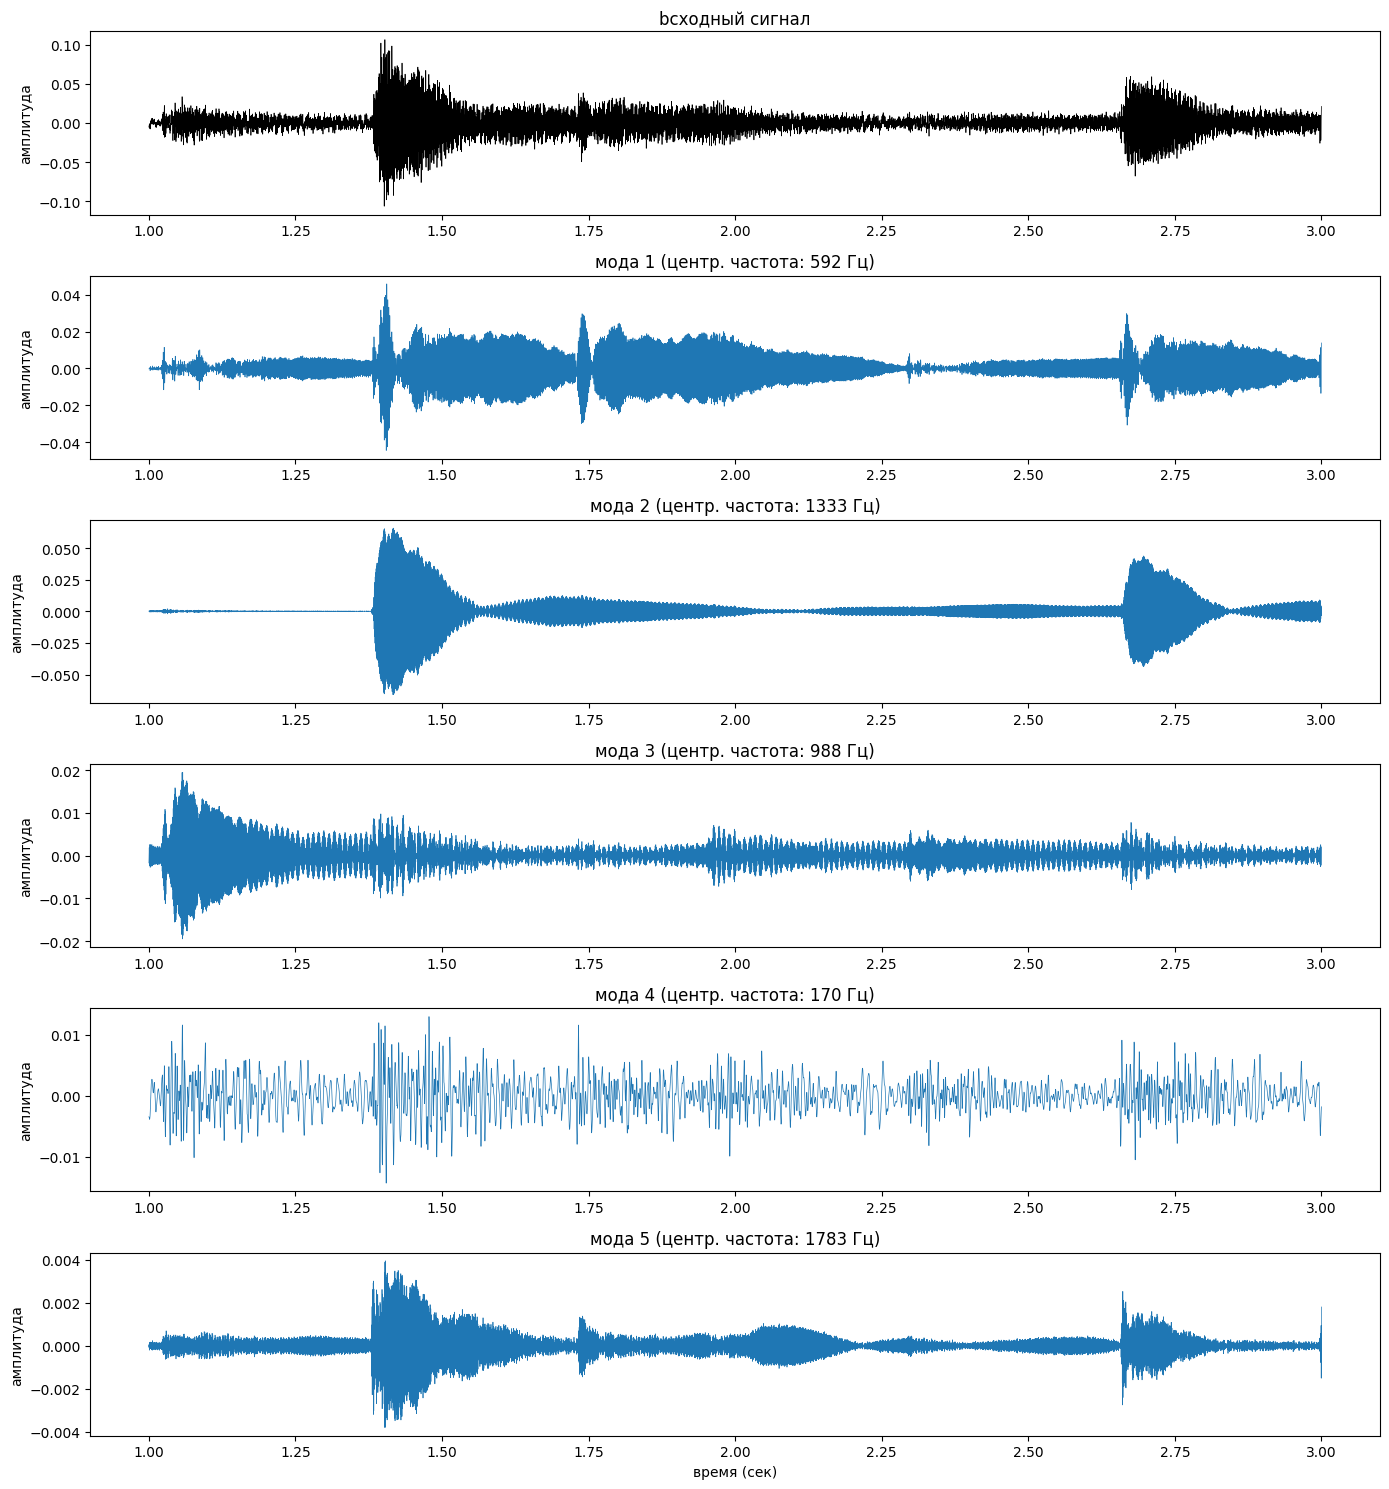

In [8]:
# вариационная модовая декомпозиция (VMD) - в отличие от EMD формулирует декомпозицию как задачу оптимизации: сигнал раскладывается на K мод, каждая из которых компактна вокруг своей центральной частоты
# параметры mvd
alpha = 2000
tau = 0.0
K = 5
DC = 0
init = 1
tol = 1e-7

# запуск VMD
u, u_hat, omega = VMD(y_fragment, alpha, tau, K, DC, init, tol)
print(f'извлечено мод: {u.shape[0]}')
print(f'центральные частоты (нормализованные): {omega[-1, :]}')

# перевод нормализованных частот в Гц
center_freqs_hz = omega[-1, :] * sr
print(f'центральные частоты (Гц): {center_freqs_hz}')

# визуализация
fig, axes = plt.subplots(K + 1, 1, figsize=(14, 2.5 * (K + 1)))

axes[0].plot(t, y_fragment, 'k', linewidth=0.5)
axes[0].set_title('bсходный сигнал')
axes[0].set_ylabel('амплитуда')

for i in range(K):
    axes[i + 1].plot(t, u[i, :], linewidth=0.5)
    axes[i + 1].set_title(f'мода {i + 1} (центр. частота: {center_freqs_hz[i]:.0f} Гц)')
    axes[i + 1].set_ylabel('амплитуда')

axes[-1].set_xlabel('время (сек)')
plt.tight_layout()